In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

# EXPLICATION : Chargement des logs depuis le fichier JSONL
# (1 JSON par ligne) - format pratique pour l'ajout incrémental d'entrées
# Le chemin relatif "../logs/predictions.jsonl" remonte d'un niveau depuis notebooks/
LOG_FILE = Path("../logs/predictions.jsonl")
df = pd.read_json(LOG_FILE, lines=True, convert_dates=['timestamp'])

# EXPLICATION : Nettoyage des "" en NaN - critique car certaines features
# peuvent manquer (représentées comme strings vides). Facilite la détection
# des anomalies plus tard.
df['input_features'] = df['input_features'].apply(lambda x: {k: None if v == "" else v for k, v in x.items()} if isinstance(x, dict) else x)
print(f"✅ {len(df)} appels chargés")

✅ 500 appels chargés


## 1. Statistiques opérationnelles de base

In [2]:
# EXPLICATION : Calcul des métriques clés pour surveiller la santé du service

# Nombre total d'appels
total_calls = len(df)
print(f"📊 Total appels : {total_calls}")

# EXPLICATION : Taux d'erreur = proportion d'appels avec une erreur enregistrée
# (error != NaN)
error_rate_pct = (df['error'].notna().sum() / total_calls) * 100
print(f"❌ Taux d'erreur : {error_rate_pct:.2f}%")

# EXPLICATION : Latence moyenne et P95 (95e percentile) pour déterminer
# si le service répond assez vite
avg_latence = df['execution_time_ms'].mean()
p95_latence = df['execution_time_ms'].quantile(0.95)
print(f"⏱️  Latence moyenne : {avg_latence:.2f} ms")
print(f"⏱️  P95 latence : {p95_latence:.2f} ms")

# EXPLICATION : Taux de refus = proportion d'appels avec prédiction = "Refusé"
# Utile pour le monitoring du pattern de décisions du modèle
refused_rate_pct = (df['output_decision'] == 'Refusé').sum() / total_calls * 100
print(f"🚫 Taux de refus : {refused_rate_pct:.2f}%")

📊 Total appels : 500
❌ Taux d'erreur : 0.00%
⏱️  Latence moyenne : 83.86 ms
⏱️  P95 latence : 188.85 ms
🚫 Taux de refus : 8.60%


## 2. Visualisations

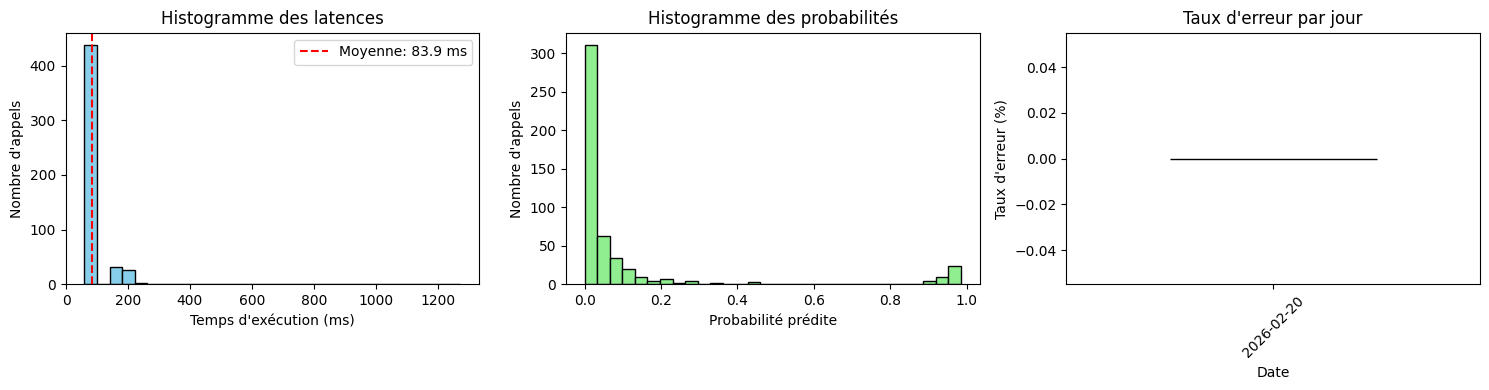

✅ Visualisations générées


In [3]:
# EXPLICATION : Créer 3 sous-graphiques pour analyser rapidement
# la distribution des latences, des probabilités et la stabilité quotidienne

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Graphique 1 : Distribution des latences (execution_time_ms)
# EXPLICATION : Montre si les appels sont rapides et constants
# ou s'il y a des outliers (appels très lents)
axes[0].hist(df['execution_time_ms'], bins=30, edgecolor='black', color='skyblue')
axes[0].set_xlabel('Temps d\'exécution (ms)')
axes[0].set_ylabel('Nombre d\'appels')
axes[0].set_title('Histogramme des latences')
axes[0].axvline(avg_latence, color='red', linestyle='--', label=f'Moyenne: {avg_latence:.1f} ms')
axes[0].legend()

# Graphique 2 : Distribution des probabilités prédites
# EXPLICATION : Montre si le modèle est confiant (pics aux extrêmes)
# ou hésitant (pics au centre)
axes[1].hist(df['output_proba'], bins=30, edgecolor='black', color='lightgreen')
axes[1].set_xlabel('Probabilité prédite')
axes[1].set_ylabel('Nombre d\'appels')
axes[1].set_title('Histogramme des probabilités')

# Graphique 3 : Taux d'erreur par jour
# EXPLICATION : Détecte si des erreurs surviennent de manière récurrente
# ou sporadique (aide à identifier une dégradation du service)
daily_error_rate = df.groupby(df['timestamp'].dt.date).apply(
    lambda x: (x['error'].notna().sum() / len(x)) * 100
)
daily_error_rate.plot(kind='bar', ax=axes[2], color='coral', edgecolor='black')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Taux d\'erreur (%)')
axes[2].set_title('Taux d\'erreur par jour')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✅ Visualisations générées")

## 3. Alertes automatiques simples

In [4]:
# EXPLICATION : Définition de seuils d'alerte simples mais efficaces
# pour détecter rapidement les problèmes opérationnels

error_rate = (df['error'].notna().mean() * 100)
p95_latence = df['execution_time_ms'].quantile(0.95)

# EXPLICATION : Seuil 5% pour taux d'erreur = niveau d'alerte modéré
# Permet de détecter les dégradations progressives
if error_rate > 5:
    print("🔴 ALERTE : Taux d'erreur > 5% !")
else:
    print(f"✅ Taux d'erreur OK ({error_rate:.2f}%)")

# EXPLICATION : Seuil 500 ms pour P95 latence = limite acceptable pour l'UX
# Les utilisateurs remarquent les délais > 500ms
if p95_latence > 500:
    print("🔴 ALERTE : P95 latence > 500 ms !")
else:
    print(f"✅ P95 latence OK ({p95_latence:.2f} ms)")

print("✅ Analyse terminée")

✅ Taux d'erreur OK (0.00%)
✅ P95 latence OK (188.85 ms)
✅ Analyse terminée
